 Introduction to Machine Learning

## Practice class 02 - Decision Trees

**Introduction**
Decision trees are a fundamental machine learning algorithm used for both classification and regression tasks. They model decisions and their possible consequences as a tree-like structure, making them intuitive and easy to interpret.

**Key Concepts**
 * **Root Node:** The starting point of the tree representing the entire dataset.
 * **Internal Nodes:** Decision points based on feature conditions.
 * **Leaf Nodes (Terminal Nodes):** Final output labels or values.
 * **Branches:** Represent the outcome of a decision rule leading to the next node.

 ![dectree](https://k21academy.com/wp-content/uploads/2020/12/decision.png)

### Demo with random points
Recall our fist example from the kNN class:

Consider 3 points in a two dimensional space $(0,0)$, $(1,0)$, $(0,1)$. Around each point generate a cloud of 30 random points with normal distribution and $\sigma=0.25$. Use 42 for the random seed. This way we have a 2 dimensional feature space with 3 species. This is going to be your train dataset.

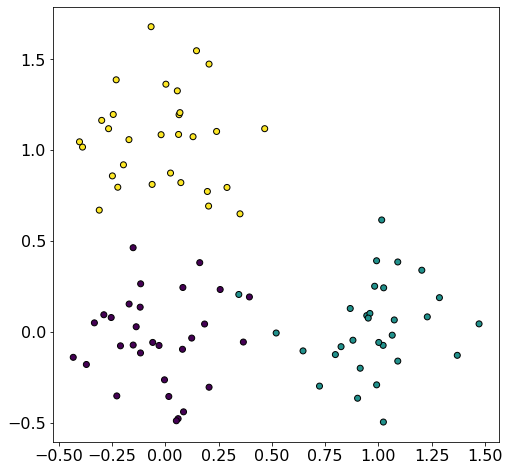

In [107]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['font.size']=16

a=np.array([0,0])
b=np.array([1,0])
c=np.array([0,1])
triangle=np.array([a,b,c])
n=30

np.random.seed(42)
x_train=np.random.normal(loc=0.0,scale=0.25,size=(3*n,2))
x_train[:n,:] += a
x_train[n:2*n,:] += b
x_train[2*n:3*n,:] += c
y_train = np.array(n*[0]+n*[1]+n*[2])

fig,ax = plt.subplots(1,1,figsize=(8,8))
im=ax.scatter(x_train[:,0],x_train[:,1],c=y_train,cmap='viridis',ec='k')


Now lets chech how a decision tree deals with this taks.

In [108]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay

In [109]:
clf = DecisionTreeClassifier(max_depth=4,criterion='gini')
clf.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=4)

[Text(0.6666666666666666, 0.9, 'x[1] <= 0.633\ngini = 0.667\nsamples = 90\nvalue = [30, 30, 30]'),
 Text(0.5, 0.7, 'x[0] <= 0.458\ngini = 0.5\nsamples = 60\nvalue = [30, 30, 0]'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'x[0] <= 0.301\ngini = 0.062\nsamples = 31\nvalue = [30, 1, 0]'),
 Text(0.16666666666666666, 0.3, 'gini = 0.0\nsamples = 28\nvalue = [28, 0, 0]'),
 Text(0.5, 0.3, 'x[0] <= 0.356\ngini = 0.444\nsamples = 3\nvalue = [2, 1, 0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0, 0]'),
 Text(0.6666666666666666, 0.5, 'gini = 0.0\nsamples = 29\nvalue = [0, 29, 0]'),
 Text(0.8333333333333334, 0.7, 'gini = 0.0\nsamples = 30\nvalue = [0, 0, 30]'),
 Text(0.75, 0.8, '  False')]

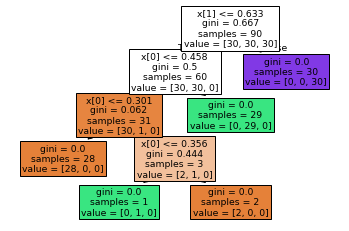

In [110]:
plot_tree(clf,filled=True)

<Figure size 432x288 with 0 Axes>

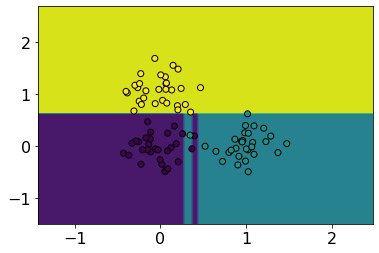

In [111]:
plt.figure()
DecisionBoundaryDisplay.from_estimator(
        clf,
        x_train,
        cmap=plt.cm.viridis,
        response_method="predict",
    )
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,edgecolor="black")

**Note that the boundaries are parallel to the coordinate axes!**

### Demo - Lets play tennis, or not?
This is a short intro how to apply decision trees for datasets with categorical data. We use a short dataset, contains 14 days of weather data, with a target coloumn of play tennis or not.

In [112]:
tennis = np.genfromtxt("tennis.txt",dtype='S10')

In [113]:
f = open("tennis.txt","r")
lines = list(f.readlines())
f.close()
names = lines[0].split()
print(names)

['#Day', 'Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis']


In [114]:
tennis

array([[b'D1', b'Sunny', b'Hot', b'High', b'Weak', b'No'],
       [b'D2', b'Sunny', b'Hot', b'High', b'Strong', b'No'],
       [b'D3', b'Overcast', b'Hot', b'High', b'Weak', b'Yes'],
       [b'D4', b'Rain', b'Mild', b'High', b'Weak', b'Yes'],
       [b'D5', b'Rain', b'Cool', b'Normal', b'Weak', b'Yes'],
       [b'D6', b'Rain', b'Cool', b'Normal', b'Strong', b'No'],
       [b'D7', b'Overcast', b'Cool', b'Normal', b'Strong', b'Yes'],
       [b'D8', b'Sunny', b'Mild', b'High', b'Weak', b'No'],
       [b'D9', b'Sunny', b'Cool', b'Normal', b'Weak', b'Yes'],
       [b'D10', b'Rain', b'Mild', b'Normal', b'Weak', b'Yes'],
       [b'D11', b'Sunny', b'Mild', b'Normal', b'Strong', b'Yes'],
       [b'D12', b'Overcast', b'Mild', b'High', b'Strong', b'Yes'],
       [b'D13', b'Overcast', b'Hot', b'Normal', b'Weak', b'Yes'],
       [b'D14', b'Rain', b'Mild', b'High', b'Strong', b'No']],
      dtype='|S10')

In [115]:
from sklearn.preprocessing import LabelEncoder # to process categorical data

xtrans = LabelEncoder()
ytrans = LabelEncoder()
X = xtrans.fit_transform(tennis[:,:-1].flatten()).reshape(tennis[:,:-1].shape)
y = ytrans.fit_transform(tennis[:,-1])

In [116]:
X,y

(array([[ 1, 22, 16, 15, 23],
        [ 7, 22, 16, 15, 21],
        [ 8, 19, 16, 15, 23],
        [ 9, 20, 17, 15, 23],
        [10, 20,  0, 18, 23],
        [11, 20,  0, 18, 21],
        [12, 19,  0, 18, 21],
        [13, 22, 17, 15, 23],
        [14, 22,  0, 18, 23],
        [ 2, 20, 17, 18, 23],
        [ 3, 22, 17, 18, 21],
        [ 4, 19, 17, 15, 21],
        [ 5, 19, 16, 18, 23],
        [ 6, 20, 17, 15, 21]]),
 array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0]))

In [117]:
clf = DecisionTreeClassifier(criterion="entropy")

In [118]:
clf.fit(X,y)

DecisionTreeClassifier(criterion='entropy')

[Text(0.4444444444444444, 0.9, 'Outlook <= 19.5\nentropy = 0.94\nsamples = 14\nvalue = [5, 9]\nclass = yes'),
 Text(0.3333333333333333, 0.7, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = yes'),
 Text(0.38888888888888884, 0.8, 'True  '),
 Text(0.5555555555555556, 0.7, 'Humidity <= 16.5\nentropy = 1.0\nsamples = 10\nvalue = [5, 5]\nclass = no'),
 Text(0.5, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'Outlook <= 21.0\nentropy = 0.722\nsamples = 5\nvalue = [4, 1]\nclass = no'),
 Text(0.2222222222222222, 0.3, 'Wind <= 22.0\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]\nclass = no'),
 Text(0.1111111111111111, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = no'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = yes'),
 Text(0.4444444444444444, 0.3, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = no'),
 Text(0.7777777777777778, 0.5, 'Wind <= 22.0\nentropy = 0.722\nsamples = 5\nvalue = [1, 4]\nclass = yes'),
 Text(0.6666666666666666, 0.

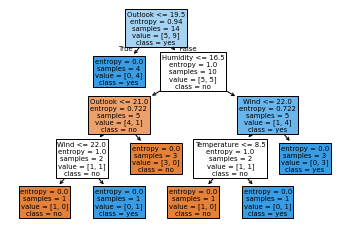

In [119]:
plot_tree(clf,feature_names=names,class_names=['no','yes'],filled=True)

### Task 1 - Gini impurity and entropy
In this task you will learn about the splitting criterias for decisions trees. There are two type of metrics applied for splitting:
* **Gini impurity:**  measures how impure or mixed a dataset is in terms of classification labels. It quantifies how often a randomly chosen element from the dataset would be incorrectly classified if randomly labeled according to the class distribution.
    $$
    I_G=1-\sum_i p_i^2
    $$

* **von Neumann entropy:** measures the uncertainty or disorder in a dataset. The goal of a decision tree is to reduce entropy by making splits that create purer subsets of data.
    $$
    H=-\sum_i p_i \text{log}_2(p_i)
    $$

1. In order to understand these quantites consider two classes and plot the Gini impurity and the von Neumann entory for $p_1\in[0,1]$. What is the value of the metrics for the pure and the most disordered cases? Note that $p_2=1-p_1$.
2. Now we have three classes. Calculate and plot the metrics for $p_1\in[0,1]$ and $p_2\in[0,1]$. Note that $p_3=1-p_1-p_2$, but with the constraint $p_1+p_2<1$. Use a heatmap plot.

/tmp/ipykernel_53852/4024022770.py:25: RuntimeWarning: invalid value encountered in log2
  entropy = -pp1*np.log2(pp1+1e-12) -pp2*np.log2(pp2+1e-12) -pp3*np.log2(pp3+1e-12)


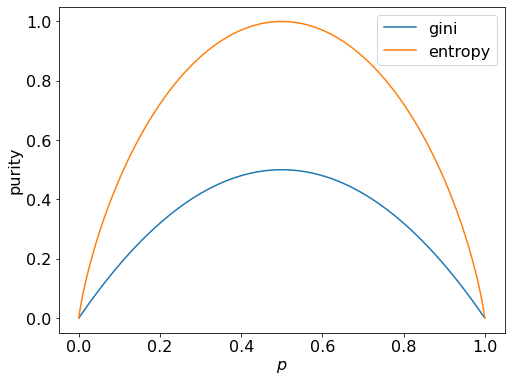

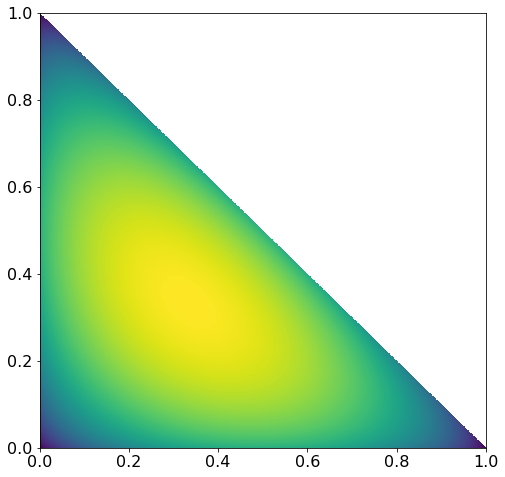

In [120]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['font.size']=16
p1=np.linspace(0,1,1000)
p2=1-p1
gini =1 - p1**2 - p2**2
entropy = -p1*np.log2(p1+1e-12) -p2*np.log2(p2+1e-12)
fig,ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(p1,gini,label='gini')
ax.plot(p1,entropy,label='entropy')
ax.set_xlabel('$p$')
ax.set_ylabel('purity')
ax.legend()

p1=np.linspace(0,1,1000)
p2=np.linspace(0,1,1000)

pp1,pp2 = np.meshgrid(p1,p2)
pp3 = -pp1 - pp2 + 1
gini =1 - pp1**2 - pp2**2 - pp3**2
gini[(pp1+pp2)>1] = np.nan

entropy = -pp1*np.log2(pp1+1e-12) -pp2*np.log2(pp2+1e-12) -pp3*np.log2(pp3+1e-12)

fig,ax = plt.subplots(1,1,figsize=(8,8))
ax.pcolormesh(pp1,pp2,entropy)


### Task 2 - Make a decision by hand 
Use the iris dataset and determine the **Root node** of the decision tree both for the Gini impurity and the von Neumann entropy. For that look for the split which minimize the total Gini impurity or the total entropy. 

1. What is the Gini impurity and the entripy of the dataset?
2. Write a helper function, going to be useful in this exercise. The function, `purity(X,y,metric)`, takes a dataset and a metric as a string and calculates the Gini impurity or the entropy of the dataset based on the `metric` arguments.
3. Select one feature, and split the data based on a threshold value of this feature. Calculate the gini/entropy of the two subsets and the total gini/entropy defined as the average of the subset values weighted by the element numbers of the subsets.
4. Split the dataset between all possible values of the given feature and plot the total gini/entropy as a function of the threshold value.
5. Repeat the previous step for all the other features, what do we have to split the data in the root node?

In [121]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

Initial Gini Impurity: 0.6667
Initial Entropy: 1.5850
Best Root Node: petal length (cm) (Threshold 2.45, Metric: gini)


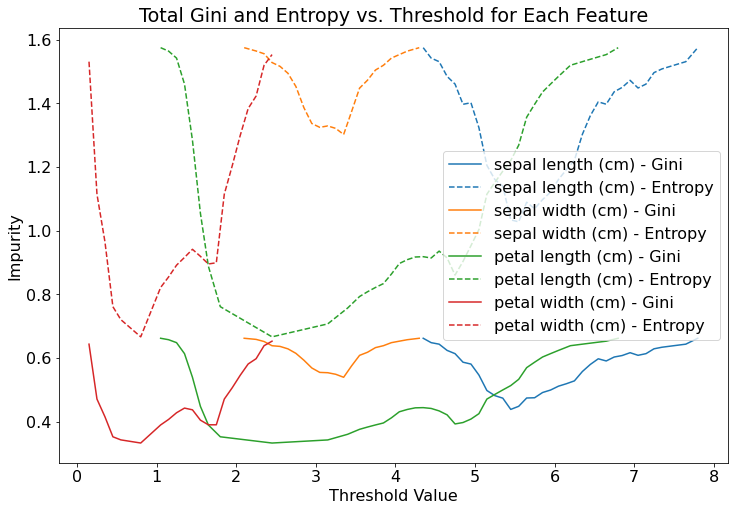

In [122]:
def purity(y, metric="gini"):
    """
    Calculate the Gini impurity or entropy of a dataset.
    :param y: Target labels
    :param metric: "gini" or "entropy"
    :return: impurity value
    """
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    
    if metric == "gini":
        return 1 - np.sum(probs ** 2)
    elif metric == "entropy":
        return -np.sum(probs * np.log2(probs + 1e-9))  # Avoid log(0)
    else:
        raise ValueError("Metric must be 'gini' or 'entropy'")

def split_data(X, y, feature_index, threshold):
    """Splits the dataset based on a feature and a threshold."""
    left_mask = X[:, feature_index] <= threshold
    right_mask = ~left_mask
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

def weighted_purity(X, y, feature_index, threshold, metric="gini"):
    """Computes the weighted impurity after a split."""
    X_left, y_left, X_right, y_right = split_data(X, y, feature_index, threshold)
    
    n = len(y)
    n_left, n_right = len(y_left), len(y_right)
    
    if n_left == 0 or n_right == 0:
        return np.inf  # Avoid empty splits
    
    return (n_left / n) * purity(y_left, metric) + (n_right / n) * purity(y_right, metric)


# Compute initial dataset impurity
initial_gini = purity(y, metric="gini")
initial_entropy = purity(y, metric="entropy")
print(f"Initial Gini Impurity: {initial_gini:.4f}")
print(f"Initial Entropy: {initial_entropy:.4f}")

# Iterate over all features to find the best split
best_feature, best_threshold, best_purity, best_metric = None, None, np.inf, None

fig,ax = plt.subplots(1,1,figsize=(12, 8))
for ind,feature_index in enumerate(range(X.shape[1])):
    thres = np.unique(X[:, feature_index])  # Unique split points
    thresholds = 0.5*(thres[1:]+thres[:-1])
    gini_values = [weighted_purity(X, y, feature_index, t, "gini") for t in thresholds]
    entropy_values = [weighted_purity(X, y, feature_index, t, "entropy") for t in thresholds]
    
    ax.plot(thresholds, gini_values, c='C{}'.format(ind), label=feature_names[feature_index]+" - Gini")
    ax.plot(thresholds, entropy_values, c='C{}'.format(ind), label=feature_names[feature_index]+" - Entropy", linestyle='dashed')
    
    # Find best split
    min_gini_idx = np.argmin(gini_values)
    min_entropy_idx = np.argmin(entropy_values)
    
    if gini_values[min_gini_idx] < best_purity:
        best_feature, best_threshold, best_purity, best_metric = feature_index, thresholds[min_gini_idx], gini_values[min_gini_idx], "gini"
    if entropy_values[min_entropy_idx] < best_purity:
        best_feature, best_threshold, best_purity, best_metric = feature_index, thresholds[min_entropy_idx], entropy_values[min_entropy_idx], "entropy"
    
ax.set_xlabel("Threshold Value")
ax.set_ylabel("Impurity")
ax.legend()
ax.set_title("Total Gini and Entropy vs. Threshold for Each Feature")

print(f"Best Root Node: {feature_names[best_feature]} (Threshold {best_threshold:.2f}, Metric: {best_metric})")


### Task 3 - How to build a decision tree
Decision trees are very easy to implement within `sklearn`. You are going to build your first decision tree for the famous iris dataset and experiment with the different parameters. The dataset is already loaded for you. 

1. Apply a train/test split with 20 % test data. 
2. Use the `DecisionTreeClassifier` function from `sklearn.tree` to define your classifier. First use `max_depth=1` to make a single decision and check you previous solution with `criterion="gini"` and `criterion="entropy"`. It works in the same fashion as the kNN classifier, with the `.fit()` method you can tran the model, and with the `.predict()` method you can make predicions. You can use the `plot_tree` function from `sklearn.tree` to visualize your tree.
3. Start to increase `max_depth`, what is the minimal depth when you reach 100 % accuracy. Use the built in `accuracy_score` to get the accuracy.
4. Write a wrapper function around your classifier. The function can modify the following arguments: `max_depth`, `criterion`, `min_samples_split`, `min_samples_leaf`, `random_state`. Train the classifier, do the prediction, calculates the accuracy and plot the tree.
5. Play also with the `min_samples_split` and `min_samples_leaf` parameters.


Decision Tree (max_depth=1, criterion=gini, min_samples_split=3, min_samples_leaf=2)
Accuracy: 0.633


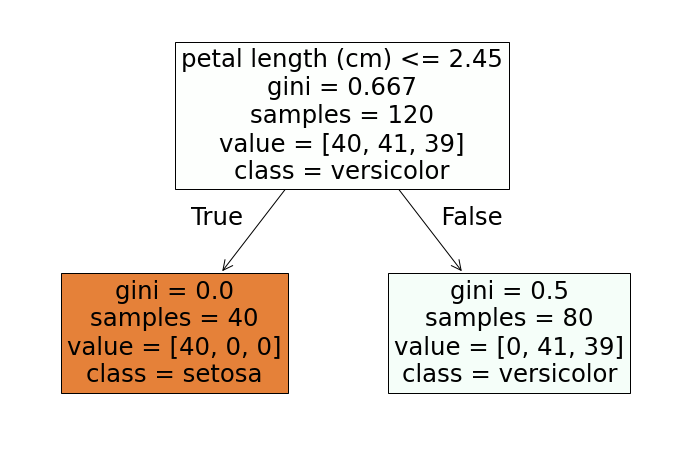

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Split dataset into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to train and evaluate a decision tree with tunable parameters
def train_decision_tree(max_depth=3, criterion="gini", min_samples_split=2, min_samples_leaf=1, random_state=42):
    # Initialize and train the Decision Tree
    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        criterion=criterion,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state
    )
    clf.fit(X_train, y_train)

    # Predictions and accuracy
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Decision Tree (max_depth={max_depth}, criterion={criterion}, min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf})")
    print(f"Accuracy: {accuracy:.3f}")

    # Plot the Decision Tree
    plt.figure(figsize=(12, 8))
    plot_tree(clf, feature_names=feature_names, class_names=class_names, filled=True)
    plt.show()

# Example: Tune the parameters
train_decision_tree(max_depth=1, criterion="gini", min_samples_split=3, min_samples_leaf=2)


### Homework - Application of decision trees for medical data

The task is to predict the presence of heart disease based on medical attributes. The dataset have already loaded for you, you just have to install `ucimlrepo` to fetch it. 

1. Read carefully the metadata, or the documentation on the website: https://archive.ics.uci.edu/dataset/45/heart+disease
2. The target data contains 5 different values but you only interested in the presence $y>0$ or the absence $y=1$ of heart disease. transform your data accordint to this (1 point)
3. Train an inital decision tree and plot your tree. Use a 80/20 train/test split. Argument in a sigle line on the parameter choice. (2 points)
4. Change the `criterion` and the `max_depth`. Plot the accuracy of your tree as a function of `max_depth` for the gini and entropy criterions. What is the optimal parameter set? Try to avoid underfitting and overfitting. Argument on your parameter choice in a single line (2 points).
5. Perform the cross-validation of your best decision tree. For the scoring use the accuracy, and apply a 5 fold split. During cross-validation each fold is then used once as a validation while the $k - 1$ remaining folds form the training set. You can use the built in cross-validation function. (2 points).
6. Download the full dataset from the webpage. You will find different datasets in it. The one used so far is the `processed.cleveland.data`. You have to apply the decesion tree trained on the cleveland data to the hungarian data can be found in `processed.hungarian.data`. For the you have to perform some manipulation with the data:
    * Drop the features missing from the hungarian data from both datasets.
    * Drop from the hungarian data each line with missing values.

   Train a decision tree with the new cleveland dataset. Apply the optimization steps from 4. and then use the optimal decision tree to predict heart disease in Hungary. Write a single line on why it works or why not? (3 points)

In [124]:
from ucimlrepo import fetch_ucirepo 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score


# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 

# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M